# S2.3 融合阶段：基于帕累托法则 (ABC分类) 的高优先级风险场景识别
本阶段目标 本笔记本旨在将 S2.1 和 S2.2 的结果进行定量融合。我们将摒弃简单的“交集筛选”，转而采用帕累托分析法 (Pareto Analysis / ABC Classification)：
量化：构建一个综合风险指数 (CRI)，同时考量风险组合的“发生频率/提升度”（来自 S2.1）和“致因重要性”（来自 S2.2）。
排序：依据 CRI 对所有风险场景进行排序。
分类：应用二八定律，识别出累积贡献度达到 80% 的 A类风险场景（高优先级），作为最终的整改建议依据。

## 步骤一.导入库与数据加载

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast  # 用于解析字符串格式的字典 "{'key': 'val'}"
import re
import os

# 设置绘图风格
sns.set(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签，如无中文字体可注释掉
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = os.path.join('..', 'data', 'processed')
RESULTS_ROOT = os.path.join('..', 'results','reports')
os.makedirs(RESULTS_ROOT, exist_ok=True)

# --- 1. 定义文件路径 ---
S2_1_FILE = os.path.join(DATA_DIR, 'high_risk_combinations_analysis_from_preprocessed.csv')
S2_2_FILE = os.path.join(DATA_DIR, 's2_2_high_contribution_features.csv')

# --- 2. 加载数据 ---
try:
    # 1. 加载原始全量文件
    df_s2_1_raw = pd.read_csv(S2_1_FILE)
    df_s2_2 = pd.read_csv(S2_2_FILE)
    
    if 'Unnamed: 0' in df_s2_2.columns:
        df_s2_2.rename(columns={'Unnamed: 0': 'feature_name'}, inplace=True)

    print("\n[原始数据加载成功]")
    print(f"S2.1 原始记录数: {len(df_s2_1_raw)}")
    
    # 参数设置：每种事故类型保留前 N 个
    TOP_N_PER_TYPE = 30  
    
    # 步骤 A: 剔除无效规则 (Uplift <= 0 的规则是负面或无意义的)
    df_filtered = df_s2_1_raw[df_s2_1_raw['uplift'] > 0].copy()
    
    # 步骤 B: 按事故类型分组，每组取 Uplift 最高的 Top N
    # 这样可以保证“稀有事故”也有代表入选，不会被“脱轨”这种大类完全淹没
    df_s2_1 = df_filtered.groupby('accident_type').apply(
        lambda x: x.sort_values('uplift', ascending=False).head(TOP_N_PER_TYPE)
    ).reset_index(drop=True)
    
    print(f"\n[筛选完成] 策略: Top {TOP_N_PER_TYPE} (每种事故类型)")
    print(f"S2.1 筛选后记录数: {len(df_s2_1)} (用于后续帕累托分析)")

    print(f"S2.2 特征重要性记录数: {len(df_s2_2)}")
    
except FileNotFoundError as e:
    print(f"\n错误：找不到文件，请检查路径。\n{e}")


[原始数据加载成功]
S2.1 原始记录数: 69552

[筛选完成] 策略: Top 30 (每种事故类型)
S2.1 筛选后记录数: 360 (用于后续帕累托分析)
S2.2 特征重要性记录数: 143


C:\Users\14704\AppData\Local\Temp\ipykernel_35332\606524680.py:42: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_s2_1 = df_filtered.groupby('accident_type').apply(


## 步骤二.特征映射与分数匹配
S2.1 的特征名是人类可读的（如 {'Equipment Type': 'Freight Train'}），而 S2.2 是机器生成的（如 cat__equipmenttype_Freight Train）。我们需要构建一个映射逻辑，将 S2.1 中的每一个条件“翻译”成 S2.2 的格式，以便查询其重要性分数。
- 如果一个组合包含多个特征（如 A 和 B），我们取它们重要性的平均值（或最大值）作为该组合的“S2.2 得分”。
- 如果某个特征在 S2.2 中找不到，则默认其重要性为 0。

In [8]:
# --- 1. 构建 S2.2 特征查询字典 ---
# 这里的 Key 是处理过的简化版特征名，Value 是重要性分数
# 目的是为了模糊匹配（忽略大小写和部分特殊字符的差异）
s2_2_dict = {}

for index, row in df_s2_2.iterrows():
    raw_name = str(row['feature_name'])
    score = row['importance_score']
    
    # 简化处理：转小写，去除 'cat__', 'num__' 前缀，去除空格
    # 例如: 'cat__Equipment Type_Freight Train' -> 'equipmenttype_freighttrain'
    simple_name = raw_name.lower().replace('cat__', '').replace('num__', '').replace(' ', '').replace('/', '').replace('.', '')
    s2_2_dict[simple_name] = score

print(f"构建了包含 {len(s2_2_dict)} 个特征的重要性查询字典。")

# --- 2. 定义映射函数 ---
def get_combination_importance(evidence_str):
    """
    解析 evidence 字符串，查找其中每个特征在 S2.2 中的重要性，
    并返回该组合的【平均重要性分数】。
    """
    try:
        # 将字符串 "{'Key': 'Val'}" 转为字典
        evidence_dict = ast.literal_eval(evidence_str)
    except:
        return 0.0
    
    scores = []
    matched_features = []
    
    for col, val in evidence_dict.items():
        # 构造尝试匹配的字符串
        # S2.2 的格式通常是: 列名_值 (对于分类) 或 列名 (对于数值)
        # 我们尝试构建几种可能的组合进行匹配
        
        # 尝试 1: 拼接 Key + Value (针对分类变量)
        query_str_1 = f"{col}_{val}".lower().replace(' ', '').replace('/', '').replace('.', '')
        
        # 尝试 2: 仅 Key (针对数值变量，S2.2里通常是 num__colname)
        query_str_2 = f"{col}".lower().replace(' ', '').replace('/', '').replace('.', '')

        score = 0.0
        if query_str_1 in s2_2_dict:
            score = s2_2_dict[query_str_1]
            matched_features.append(f"{col}={val}(Score:{score:.4f})")
        elif query_str_2 in s2_2_dict:
            score = s2_2_dict[query_str_2]
            matched_features.append(f"{col}(Score:{score:.4f})")
        else:
            # 没找到匹配，分数为 0
            matched_features.append(f"{col}={val}(N/A)")
            
        scores.append(score)
    
    # 计算平均重要性 (如果组合里有多个条件，取平均值代表该组合的整体致因强度)
    avg_importance = np.mean(scores) if scores else 0.0
    return avg_importance, "; ".join(matched_features)

# --- 3. 应用映射 ---
# 在 S2.1 DataFrame 中添加 's2_2_importance' 列
results = df_s2_1.apply(lambda row: get_combination_importance(row['evidence']), axis=1, result_type='expand')
df_s2_1['s2_2_importance'] = results[0]
df_s2_1['matched_details'] = results[1]

print("特征匹配完成。前 5 行预览：")
display(df_s2_1[['accident_type', 'evidence', 'uplift', 's2_2_importance']].head())

构建了包含 142 个特征的重要性查询字典。
特征匹配完成。前 5 行预览：


,accident_type,evidence,uplift,s2_2_importance
0,Broken train collision,{'Equipment Type': 'Cut of cars'},0.012954,0.001083
1,Broken train collision,"{'Hazmat Cars Damaged': '0', 'Equipment Type':...",0.012954,0.000541
2,Broken train collision,"{'Visibility': 'Dark', 'Equipment Type': 'Cut ...",0.012954,0.001825
3,Broken train collision,"{'Visibility': 'Day', 'Equipment Type': 'Cut o...",0.012954,0.004032
4,Broken train collision,"{'Weather Condition': 'Clear', 'Equipment Type...",0.012954,0.001118


## 步骤三.构建综合风险指数 (CRI)
归一化与加权为了进行公平比较，需要消除量纲影响。
- Uplift (S2.1)：范围通常在 0.0 ~ 0.5 之间。
- Importance (S2.2)：范围通常在 0.0 ~ 0.05 之间。
我们将使用 Min-Max 归一化 将它们都映射到 [0, 1] 区间。综合得分公式：
$$\text{CRI} = w_1 \times \text{Norm}(\text{Uplift}) + w_2 \times \text{Norm}(\text{Importance})$$
- 权重设定：建议设定 $w_1=0.5, w_2=0.5$（S2.1与S2.2同等重要）。如果更信任 XGBoost 的判断，可以提高 $w_2$。

In [9]:
# --- 1. 归一化函数 ---
def min_max_norm(series):
    return (series - series.min()) / (series.max() - series.min())

# --- 2. 执行归一化 ---
df_s2_1['norm_uplift'] = min_max_norm(df_s2_1['uplift'])
df_s2_1['norm_importance'] = min_max_norm(df_s2_1['s2_2_importance'])

# --- 3. 计算综合风险指数 (CRI) ---
# 权重设定 (可调整)
W1 = 0.5  # 频率/提升度 (S2.1) 的权重
W2 = 0.5  # 致因重要性 (S2.2) 的权重

df_s2_1['CRI_Score'] = W1 * df_s2_1['norm_uplift'] + W2 * df_s2_1['norm_importance']

# --- 4. 排序 ---
# 按 CRI 从高到低排序
df_pareto = df_s2_1.sort_values(by='CRI_Score', ascending=False).reset_index(drop=True)

print("综合评分计算完成。")

综合评分计算完成。


## 步骤四.帕累托分析 (ABC分类)
根据论文方法论，计算 **累积贡献度** (Cumulative Contribution)。
- A 类 (0% - 80%)：核心风险场景。这是我们需要重点汇报和整改的“关键少数”。
- B 类 (80% - 90%)：次要风险场景。
- C 类 (90% - 100%)：一般风险场景。

--- ABC 分类结果统计 ---
Class
A    180
B     60
C    120
Name: count, dtype: int64


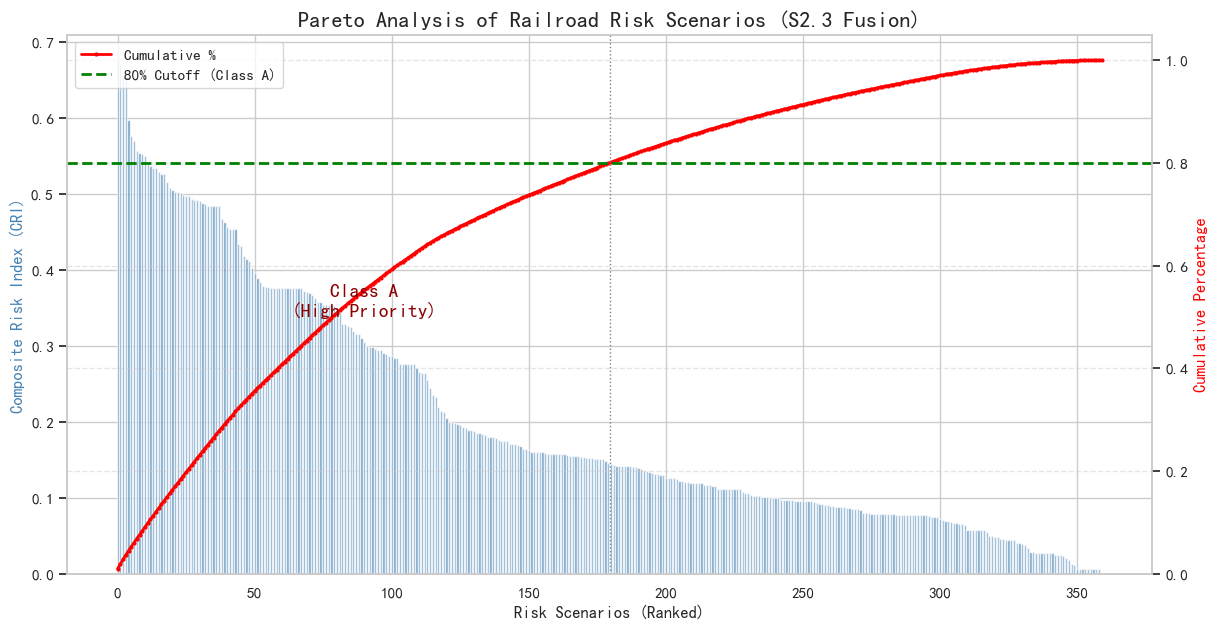

In [10]:
# --- 1. 计算累积百分比 ---
# 计算 CRI 分数的总和
total_score = df_pareto['CRI_Score'].sum()

# 计算累积得分
df_pareto['cumulative_score'] = df_pareto['CRI_Score'].cumsum()

# 计算累积百分比
df_pareto['cumulative_percentage'] = df_pareto['cumulative_score'] / total_score

# --- 2. 划分 ABC 类 ---
def get_abc_class(percentage):
    if percentage <= 0.80:
        return 'A'
    elif percentage <= 0.90:
        return 'B'
    else:
        return 'C'

df_pareto['Class'] = df_pareto['cumulative_percentage'].apply(get_abc_class)

# 统计各类别数量
class_counts = df_pareto['Class'].value_counts().sort_index()
print("--- ABC 分类结果统计 ---")
print(class_counts)

# --- 3. 帕累托图可视化 ---
plt.figure(figsize=(14, 7))

# 柱状图：每个场景的 CRI Score
ax1 = plt.gca()
ax1.bar(df_pareto.index, df_pareto['CRI_Score'], color='steelblue', alpha=0.7, label='Individual CRI Score')
ax1.set_xlabel('Risk Scenarios (Ranked)', fontsize=12)
ax1.set_ylabel('Composite Risk Index (CRI)', fontsize=12, color='steelblue')

# 折线图：累积百分比
ax2 = ax1.twinx()
ax2.plot(df_pareto.index, df_pareto['cumulative_percentage'], color='red', marker='o', markersize=2, linewidth=2, label='Cumulative %')
ax2.set_ylabel('Cumulative Percentage', fontsize=12, color='red')
ax2.set_ylim(0, 1.05)

# 绘制 80% 分界线 (A/B 类分界)
ax2.axhline(y=0.8, color='green', linestyle='--', linewidth=2, label='80% Cutoff (Class A)')

# 标注 A 类区域
a_class_count = class_counts.get('A', 0)
plt.axvline(x=a_class_count - 0.5, color='gray', linestyle=':', linewidth=1)
plt.text(a_class_count / 2, 0.5, 'Class A\n(High Priority)', ha='center', fontsize=14, color='darkred')

plt.title('Pareto Analysis of Railroad Risk Scenarios (S2.3 Fusion)', fontsize=16)
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## 步骤五.输出A类风险报告

In [11]:
# --- 导出最终的 A 类风险列表 ---
df_class_a = df_pareto[df_pareto['Class'] == 'A'].copy()

# 整理输出列，使其更易读
output_cols = ['Class', 'accident_type', 'evidence', 'uplift', 's2_2_importance', 'CRI_Score', 'matched_details']
df_final_report = df_class_a[output_cols]

print(f"--- 最终识别出 {len(df_final_report)} 个 A 类高优先级风险场景 ---")
display(df_final_report.head(10))
# 保存到 CSV
output_filename = 's2_3_final_pareto_risk_scenarios.csv'
output_path = os.path.join(RESULTS_ROOT, output_filename)
df_final_report.to_csv(output_path, index=False)
print(f"\n结果已保存至: {output_path}")

--- 最终识别出 180 个 A 类高优先级风险场景 ---


,Class,accident_type,evidence,uplift,s2_2_importance,CRI_Score,matched_details
0,A,Hwy-rail crossing,"{'Track Type': 'Main', 'Passengers Transported...",0.492213,0.005642,0.675803,Track Type=Main(Score:0.0113); Passengers Tran...
1,A,Hwy-rail crossing,"{'First Car Position': '1.0', 'Passengers Tran...",0.483765,0.005747,0.670688,First Car Position(Score:0.0115); Passengers T...
2,A,Derailment,"{'Track Type': 'Yard', 'Equipment Type': 'Frei...",0.156207,0.015375,0.653334,Track Type=Yard(Score:0.0184); Equipment Type=...
3,A,Other impacts,"{'Equipment Attended': 'No', 'Equipment Type':...",0.229662,0.013074,0.652605,Equipment Attended=No(Score:0.0231); Equipment...
4,A,Hwy-rail crossing,"{'Passengers Transported': 'Yes', 'Visibility'...",0.483915,0.003491,0.597473,Passengers Transported=Yes(Score:0.0000); Visi...
5,A,Other impacts,"{'Track Type': 'Yard', 'Equipment Type': 'Sing...",0.229662,0.010718,0.575981,Track Type=Yard(Score:0.0184); Equipment Type=...
6,A,Other impacts,"{'Equipment Attended': 'No', 'Head End Locomot...",0.156750,0.012790,0.569817,Equipment Attended=No(Score:0.0231); Head End ...
7,A,Hwy-rail crossing,"{'Passengers Transported': 'Yes', 'Class': '1L'}",0.483513,0.002247,0.556631,Passengers Transported=Yes(Score:0.0000); Clas...
8,A,Derailment,{'Equipment Type': 'Freight Train'},0.156207,0.012314,0.553781,Equipment Type=Freight Train(Score:0.0123)
9,A,Hwy-rail crossing,"{'Track Class': '4', 'Passengers Transported':...",0.492054,0.001845,0.552174,Track Class=4(Score:0.0037); Passengers Transp...



结果已保存至: ..\results\reports\s2_3_final_pareto_risk_scenarios.csv
